# Week 7 – the MNIST network in PyTorch
COS30018 Lab 7. The lab sheet introduces **both** TensorFlow and PyTorch, so after the Keras notebooks I rebuilt the network in PyTorch: 784 → 128 → 64 → 10 with ReLU, Adam, 5 epochs (the same as experiment 7/8 in `nn_experiments.ipynb`, just fewer epochs).

*Why a separate notebook:* when I ran TensorFlow training and PyTorch training in the same Jupyter kernel, the kernel crashed (segfault – the two libraries clash over threading libraries). Separate kernels = no problem.

In [1]:
import os, time, urllib.request
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

print("PyTorch", torch.__version__, "| CUDA GPU available:", torch.cuda.is_available())

# same MNIST file Keras downloads (tf.keras.datasets.mnist) - grab it directly so this notebook doesn't need TensorFlow
path = os.path.expanduser("~/.keras/datasets/mnist.npz")
if not os.path.exists(path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    urllib.request.urlretrieve("https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz", path)
with np.load(path) as f:
    x_train, y_train, x_test, y_test = f["x_train"], f["y_train"], f["x_test"], f["y_test"]

# same preprocessing as neural_net.ipynb: scale to 0-1 and flatten 28x28 -> 784
Xtr = torch.tensor(x_train.reshape(-1, 784) / 255, dtype=torch.float32); Ytr = torch.tensor(y_train, dtype=torch.long)
Xte = torch.tensor(x_test.reshape(-1, 784) / 255, dtype=torch.float32); Yte = torch.tensor(y_test, dtype=torch.long)
print(Xtr.shape, Xte.shape)

PyTorch 2.14.1+cu130 | CUDA GPU available: False
torch.Size([60000, 784]) torch.Size([10000, 784])


In [2]:
torch.manual_seed(42)
net = nn.Sequential(nn.Linear(784, 128), nn.ReLU(),
                    nn.Linear(128, 64), nn.ReLU(),
                    nn.Linear(64, 10))            # no softmax here: CrossEntropyLoss applies it
print(net)
print("trainable parameters:", sum(p.numel() for p in net.parameters()))

opt = torch.optim.Adam(net.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()                   # = softmax + categorical cross-entropy

history = []
t0 = time.time()
for epoch in range(5):
    net.train()
    perm = torch.randperm(len(Xtr))
    running = 0.0
    for k in range(0, len(Xtr), 32):
        idx = perm[k:k + 32]
        opt.zero_grad()                           # 1. reset the gradients
        out = net(Xtr[idx])                       # 2. forward pass
        loss = loss_fn(out, Ytr[idx])             # 3. loss
        loss.backward()                           # 4. backpropagation
        opt.step()                                # 5. gradient descent update
        running += loss.item() * len(idx)
    net.eval()
    with torch.no_grad():
        acc = (net(Xte).argmax(1) == Yte).float().mean().item()
    history.append((running / len(Xtr), acc))
    print(f"epoch {epoch + 1}: train loss {running / len(Xtr):.4f} | test accuracy {acc:.4f}")
print(f"done in {time.time() - t0:.0f}s on CPU")

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=10, bias=True)
)
trainable parameters: 109386
epoch 1: train loss 0.2831 | test accuracy 0.9546
epoch 2: train loss 0.1163 | test accuracy 0.9699
epoch 3: train loss 0.0787 | test accuracy 0.9725
epoch 4: train loss 0.0589 | test accuracy 0.9768
epoch 5: train loss 0.0458 | test accuracy 0.9761
done in 18s on CPU


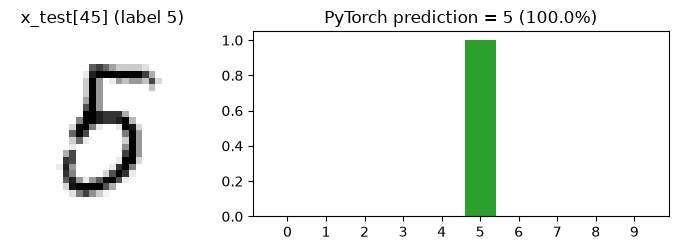

In [3]:
with torch.no_grad():
    probs = torch.softmax(net(Xte[45:46]), dim=1)[0].numpy()
fig, axes = plt.subplots(1, 2, figsize=(7, 2.6), gridspec_kw={"width_ratios": [1, 2]})
axes[0].imshow(x_test[45], cmap="gray_r"); axes[0].axis("off"); axes[0].set_title(f"x_test[45] (label {y_test[45]})")
axes[1].bar(range(10), probs, color=["tab:green" if d == probs.argmax() else "tab:grey" for d in range(10)])
axes[1].set_xticks(range(10)); axes[1].set_title(f"PyTorch prediction = {probs.argmax()} ({probs.max():.1%})")
plt.tight_layout(); plt.show()

Pretty much the same accuracy as the Keras version with Adam. Same maths underneath, the difference is the style:

| | Keras | PyTorch |
|---|---|---|
| define model | `Sequential([... Dense ...])` | `nn.Sequential(nn.Linear, nn.ReLU, ...)` |
| training | `compile()` + `fit()` does the loop | write the loop: `zero_grad → forward → loss → backward → step` |
| softmax | in the last layer | inside `CrossEntropyLoss` |

PyTorch is more code, but every step from the lab sheet (forward pass, loss, backprop, gradient descent) is right there in the loop.